# Packages and data

# Calling in necessary packages

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import seaborn as sns
import itertools
import math

!pip install pyproj
!pip install adjustText


from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

from scipy.stats import gaussian_kde
from scipy import stats
from scipy.stats import linregress
from scipy.stats import shapiro, ks_2samp, levene, ttest_ind, mannwhitneyu
from collections import OrderedDict


from pyproj import Transformer

from adjustText import adjust_text

## Calling in data

In [8]:
df2 = pd.read_csv("Profiles.csv")
df3 = pd.read_csv("XSection.csv")

# Fig. S3: Fan profiles

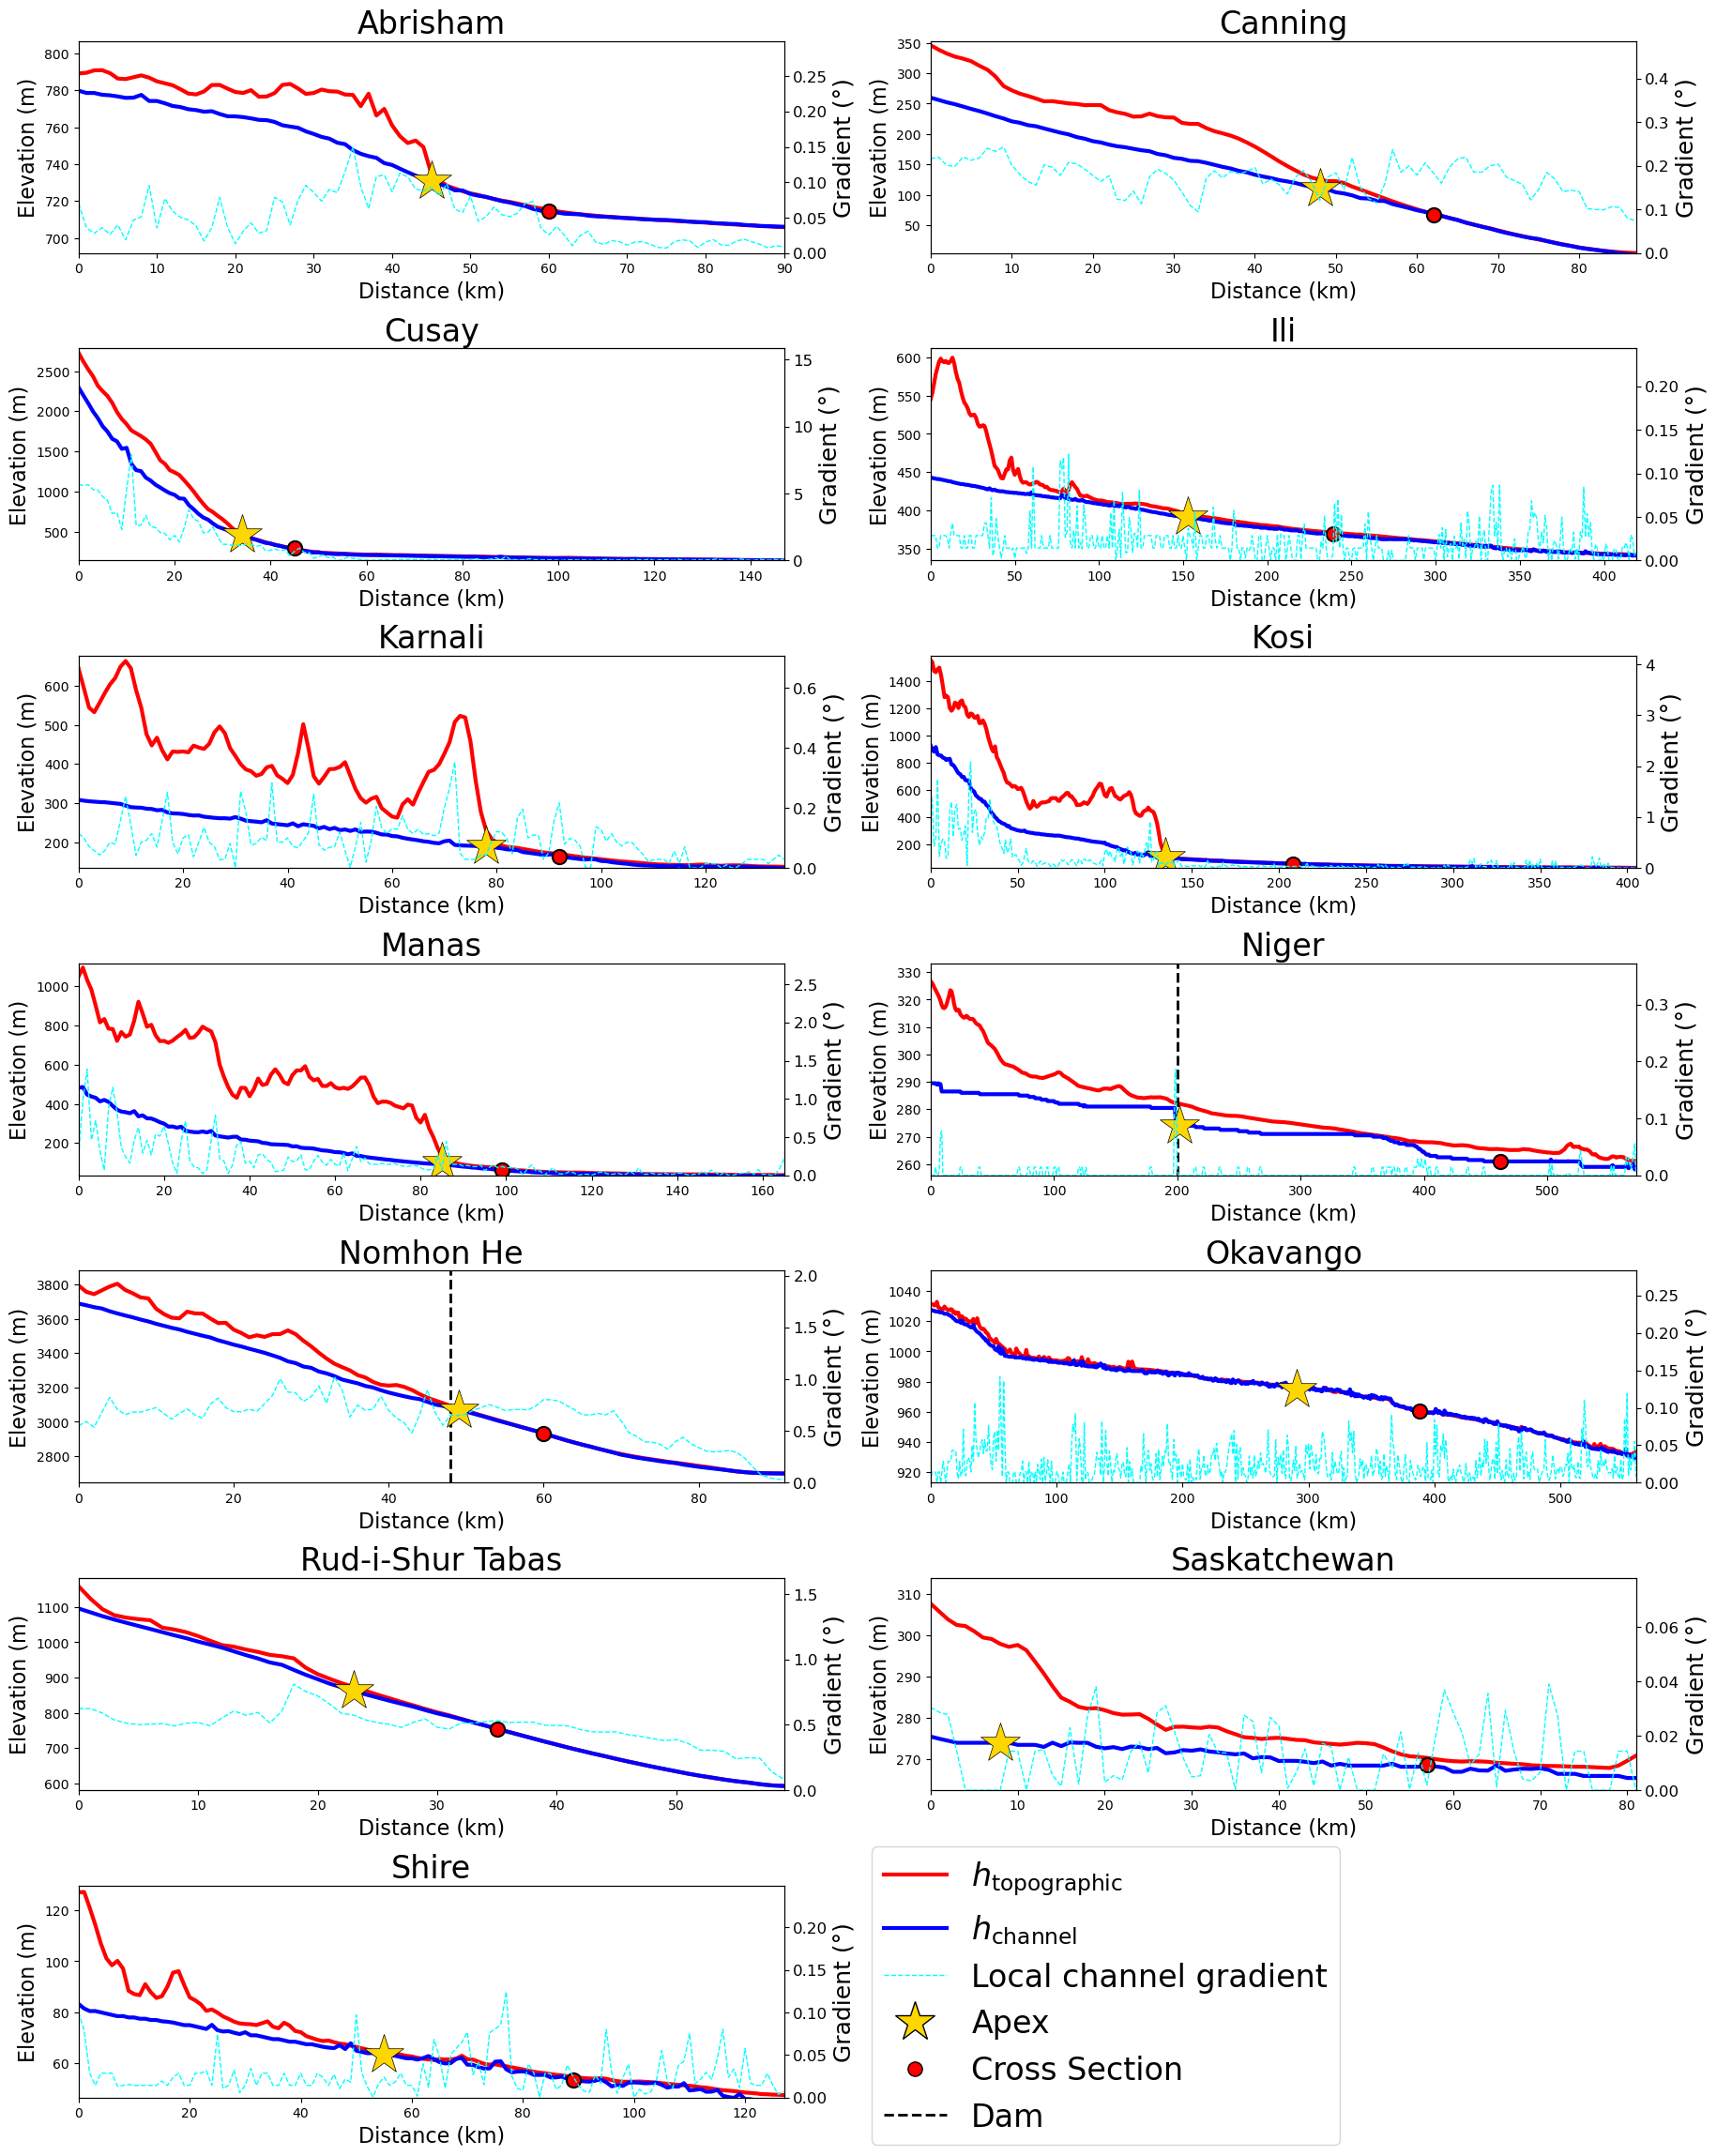

In [9]:
# -------------------------------
# Strip column names
df2.columns = df2.columns.str.strip()

# List of unique fans
fan_list = df2['Fan'].unique()

# Optional: manual Dam markers per fan
dam_dict = {
    'Nomhon He': [48],
    'Niger': [200]
}

# Smoothing window sizes
window_topo = 1
window_river = 1
window_slope = 1

# -------------------------------
# Subplot layout: 2 columns, dynamic rows
ncols = 2
nrows = int(np.ceil(len(fan_list) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.4 * nrows))
axes = axes.flatten()

# Prepare legend handles for global legend (match actual plot sizes)
apex_marker_size = 1000  # same as s in scatter
cross_marker_size = 120  # same as s in scatter

apex_legend = plt.Line2D([0], [0], marker='*', color='gold', markerfacecolor='gold',
                         markersize=np.sqrt(apex_marker_size), markeredgecolor='black', linewidth=0)
cross_legend = plt.Line2D([0], [0], marker='o', color='red', markerfacecolor='red',
                          markersize=np.sqrt(cross_marker_size), markeredgecolor='black', linewidth=0)
dam_legend = plt.Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Dam')

# -------------------------------
# Loop through each fan
for i, fan_name in enumerate(fan_list):
    ax1 = axes[i]

    # Filter and sort
    df_fan = df2[df2['Fan'] == fan_name].copy().sort_values("Distance")

    # Interpolate missing values
    df_fan['Mean Elevation'] = df_fan['Mean Elevation'].interpolate(method='linear')
    df_fan['Topo_elev_smooth'] = df_fan['Mean Elevation'].rolling(window=window_topo, center=True).mean()
    df_fan['River_elev_smooth'] = df_fan['River Elevation'].rolling(window=window_river, center=True).mean()

    # River slope
    gradient_river = np.gradient(df_fan['River Elevation'], df_fan['Distance'] * 1000)
    df_fan['River_slope_deg'] = np.degrees(np.arctan(np.abs(gradient_river)))
    df_fan['River_slope_deg_smooth'] = df_fan['River_slope_deg'].rolling(window=window_slope, center=True).mean()

    # Plot elevations
    topo_line, = ax1.plot(df_fan['Distance'], df_fan['Topo_elev_smooth'],
                          color='red', linewidth=3, zorder=1)
    river_line, = ax1.plot(df_fan['Distance'], df_fan['River_elev_smooth'],
                           color='blue', linewidth=3, zorder=2)

    # Vertical dashed lines for Dams
    for dam in dam_dict.get(fan_name, []):
        ax1.axvline(x=dam, color='black', linestyle='--', linewidth=2, zorder=3)

    # Apex marker (yellow star)
    if 'Apex' in df_fan.columns:
        apex_data = df_fan[df_fan['Apex'] == 'Apex']
        if not apex_data.empty:
            ax1.scatter(apex_data['Distance'], df_fan.loc[apex_data.index, 'River_elev_smooth'],
                        marker='*', s=apex_marker_size, color='gold', edgecolor='black', linewidths=0.5, zorder=5)

    # Cross Section marker (red circle)
    cross_data = df_fan[df_fan['Cross Section'] == 'Cross Section']
    if not cross_data.empty:
        ax1.scatter(cross_data['Distance'], df_fan.loc[cross_data.index, 'River_elev_smooth'],
                    marker='o', s=cross_marker_size, color='red', edgecolor='black', linewidths=1.5, zorder=6)

    # Dynamic y-limits for elevation
    ymin, ymax = df_fan['Topo_elev_smooth'].min(), df_fan['Topo_elev_smooth'].max()
    ax1.set_ylim(0.98 * ymin, 1.02 * ymax)

    # Force x-axis to go exactly from first to last data point
    ax1.set_xlim(df_fan['Distance'].min(), df_fan['Distance'].max())
    ax1.margins(x=0)  # remove extra horizontal padding

    ax1.set_xlabel('Distance (km)', fontsize=16)
    ax1.set_ylabel('Elevation (m)', fontsize=16)
    ax1.tick_params(axis='both', labelsize=10)
    ax1.set_title(fan_name, fontsize=24)

    # Secondary axis: slope
    ax2 = ax1.twinx()
    slope_line, = ax2.plot(df_fan['Distance'], df_fan['River_slope_deg_smooth'],
                           color='cyan', linestyle='--', linewidth=1, zorder=1)
    ax2.set_ylabel('Gradient (°)', fontsize=18)
    ax2.tick_params(axis='y', labelsize=12)
    max_slope = df_fan['River_slope_deg_smooth'].max()
    ax2.set_ylim(0, 2 * max_slope if max_slope > 0 else 0.5)

# Hide unused subplots
for j in range(len(fan_list), len(axes)):
    axes[j].axis('off')

# -------------------------------
# Single global legend at lower-right (updated labels)
# -------------------------------
fig.legend(
    [topo_line, river_line, slope_line, apex_legend, cross_legend, dam_legend],
    [r"$h_{\mathrm{topographic}}$", r"$h_{\mathrm{channel}}$", "Local channel gradient", "Apex", "Cross Section", "Dam"],
    loc="lower right",
    fontsize=24,
    ncol=1,
    bbox_to_anchor=(0.725, 0.0)
)

plt.tight_layout(rect=[0, 0, 0.92, 0.97])
plt.show()


In [14]:
# Calculating fan concavity
concavity_list = []

df2.columns = df2.columns.str.strip()

for fan_name in df2["Fan"].unique():

    df_fan = (
        df2[df2["Fan"] == fan_name]
        .sort_values("Distance")
        .reset_index(drop=True)
    )

    # find apex position safely
    apex_rows = df_fan[df_fan["Apex"].isin(["Apex", "Both", "Yes"])]

    if apex_rows.empty:
        continue

    apex_idx = apex_rows.index[0]   # now safe (0-based after reset)

    # downstream segment
    ds = df_fan.iloc[apex_idx:].copy()

    if len(ds) < 5:
        continue

    x = ds["Distance"].values
    z = ds["River Elevation"].values

    x = x - x.min()

    a, b, c = np.polyfit(x, z, 2)

    concavity_list.append({
        "Fan": fan_name,
        "Concavity": a
    })

concavity_df = pd.DataFrame(concavity_list)

print(concavity_df)
print("Number of fans with concavity:", len(concavity_df))

                 Fan  Concavity
0           Abrisham   0.013822
1            Canning   0.015968
2              Cusay   0.029610
3                Ili   0.000291
4            Karnali   0.023272
5               Kosi   0.001172
6              Manas   0.014041
7              Niger  -0.000005
8          Nomhon He   0.163588
9           Okavango  -0.000139
10  Rud-i-Shur Tabas   0.075777
11      Saskatchewan   0.000328
12             Shire   0.000054
Number of fans with concavity: 13


In [15]:
# Defining fan groups
FAN_GROUPS = {
    "Subgroup 1a": ["Ili", "Abrisham", "Niger"],
    "Subgroup 1b": ["Saskatchewan", "Shire", "Okavango"],
    "Subgroup 2a": ["Canning", "Karnali", "Kosi", "Manas"],
    "Subgroup 2b": ["Nomhon He", "Rud-i-Shur Tabas", "Cusay"]
}

In [16]:
# Dispalying last 1 km gradient for each fan
for group_name, fans in FAN_GROUPS.items():

    print(f"\n=== {group_name} ===")

    for fan_name in fans:

        df_fan = df2[df2['Fan'] == fan_name].copy().sort_values("Distance")

        # Skip if fan not found
        if df_fan.empty:
            print(f"{fan_name}: NA")
            continue

        # --- slope calc ---
        gradient_river = np.gradient(df_fan['River Elevation'], df_fan['Distance'] * 1000)
        df_fan['River_slope_deg'] = np.degrees(np.arctan(np.abs(gradient_river)))
        df_fan['River_slope_deg_smooth'] = df_fan['River_slope_deg'].rolling(window=window_slope, center=True).mean()

        # --- Last 1 km ---
        max_dist = df_fan['Distance'].max()
        last_1km = df_fan[df_fan['Distance'] >= max_dist - 1]
        last1km_mean_slope = last_1km['River_slope_deg_smooth'].mean()

        # --- Apex ---
        apex_slope = np.nan
        if 'Apex' in df_fan.columns:
            apex_data = df_fan[df_fan['Apex'] == 'Apex']
            if not apex_data.empty:
                apex_slope = df_fan.loc[apex_data.index, 'River_slope_deg_smooth'].mean()

        # --- Print ---
        print(f"{fan_name}: "
              f"Last 1 km = {last1km_mean_slope:.4f}°, "
              f"Apex = {apex_slope:.4f}°")


=== Subgroup 1a ===
Ili: Last 1 km = 0.0076°, Apex = 0.0373°
Abrisham: Last 1 km = 0.0097°, Apex = 0.0928°
Niger: Last 1 km = 0.0297°, Apex = 0.0000°

=== Subgroup 1b ===
Saskatchewan: Last 1 km = 0.0072°, Apex = 0.0000°
Shire: Last 1 km = 0.0054°, Apex = 0.0240°
Okavango: Last 1 km = 0.0315°, Apex = 0.0061°

=== Subgroup 2a ===
Canning: Last 1 km = 0.0769°, Apex = 0.1209°
Karnali: Last 1 km = 0.0358°, Apex = 0.0430°
Kosi: Last 1 km = 0.0000°, Apex = 0.0603°
Manas: Last 1 km = 0.1518°, Apex = 0.0716°

=== Subgroup 2b ===
Nomhon He: Last 1 km = 0.0327°, Apex = 0.6480°
Rud-i-Shur Tabas: Last 1 km = 0.1105°, Apex = 0.5739°
Cusay: Last 1 km = 0.0681°, Apex = 1.1145°


# Fig. S4: Fan cross-section profiles

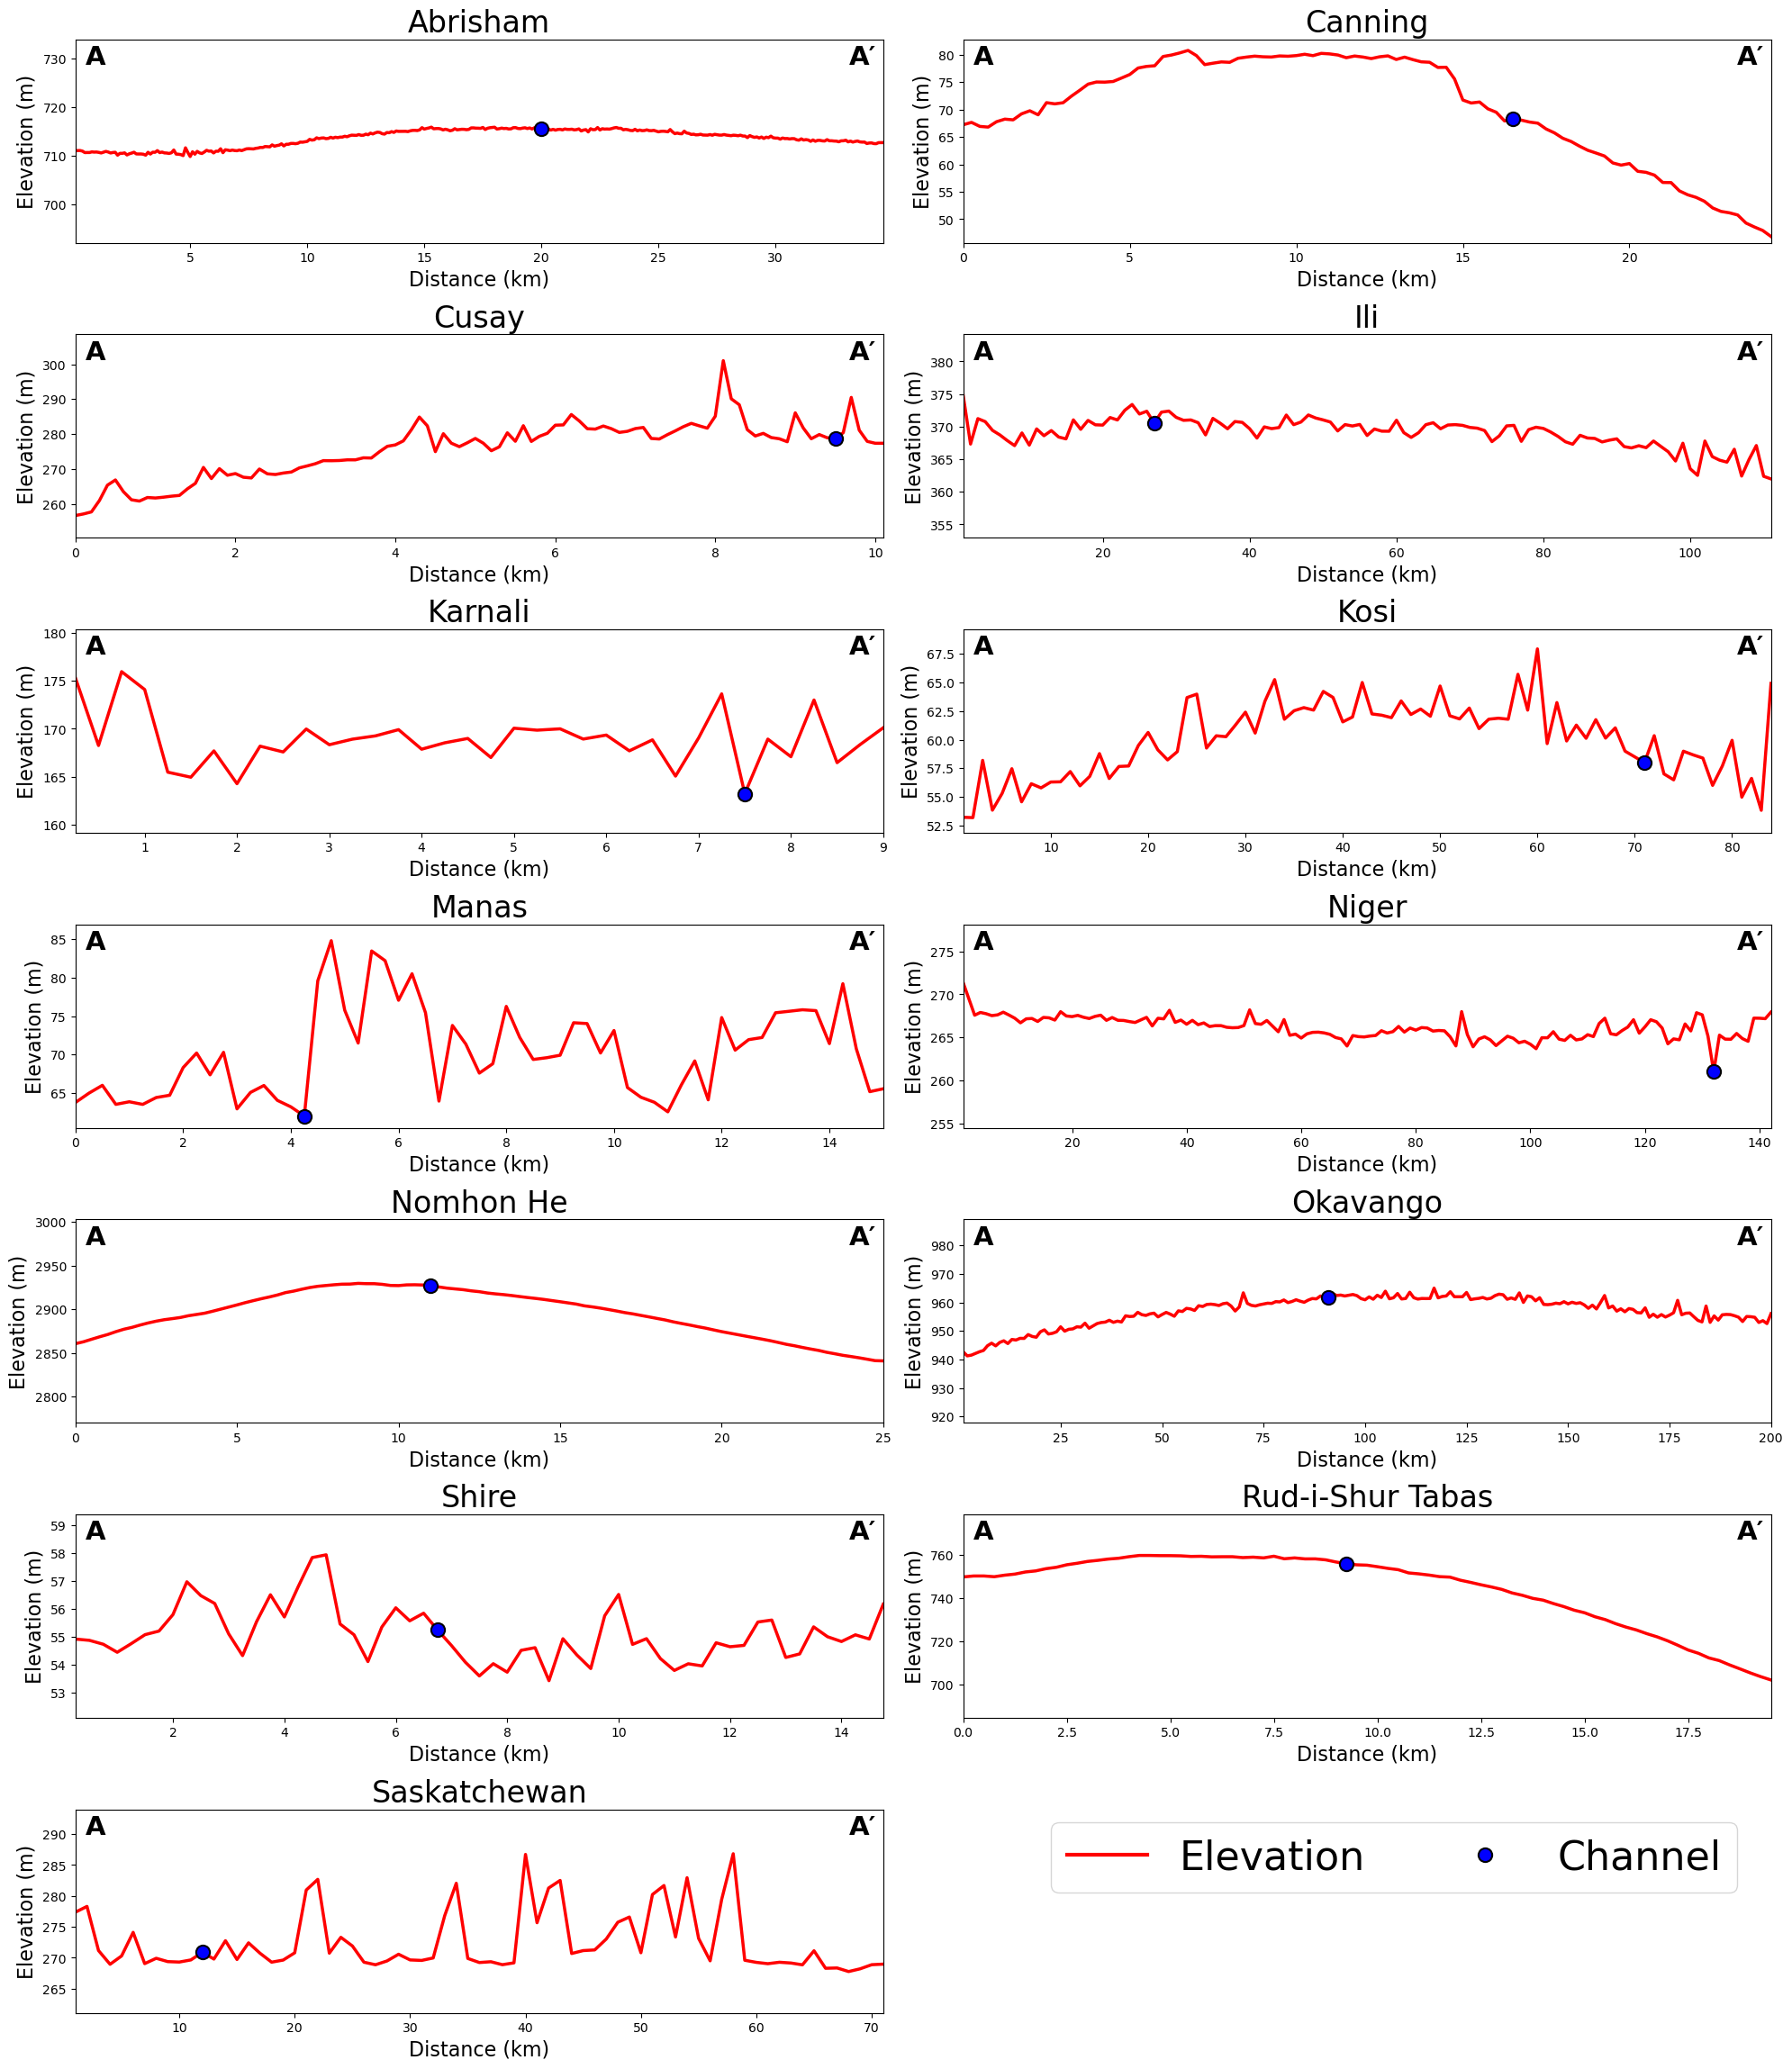

In [17]:
# -------------------------------
# Get unique fans from df3
fan_list = df3['Fan'].unique()
channel_circle_size = 120  # same as cross-section
channel_edgewidth = 1.5

# -------------------------------
# Cross-section label offsets
x_offset = 0.025  # relative x-position for A/A′
y_fixed = 0.975  # relative y-position for A/A′
label_size = 21  # font size for A/A′

# -------------------------------
# Create 2-column subplot grid (rows adjust automatically)
ncols = 2
nrows = int(np.ceil(len(fan_list) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.4 * nrows))
axes = axes.flatten()

# -------------------------------
# Loop through each fan and plot
for i, fan_name in enumerate(fan_list):
    ax = axes[i]
    
    # Filter and sort
    df_fan = df3[df3['Fan'] == fan_name].copy().sort_values("Distance")
    df_fan['Elevation'] = df_fan['Elevation'].interpolate(method='linear')
    
    # Red line: cross-section elevation
    ax.plot(df_fan['Distance'], df_fan['Elevation'], color='red', linewidth=2.5, zorder=1)

    # Blue circles: channel points (match cross-section style)
    df_channel = df_fan[df_fan['Channel'] == "Channel"]
    ax.scatter(df_channel['Distance'], df_channel['Elevation'],
               color='blue', s=channel_circle_size,
               edgecolor='black', linewidths=channel_edgewidth,
               marker='o', zorder=2)
    
    # Axis formatting
    ymin, ymax = df_fan['Elevation'].min(), df_fan['Elevation'].max()
    ax.set_ylim(0.975 * ymin, 1.025 * ymax)
    ax.margins(x=0)  #  horizontal whitespace

    ax.set_title(fan_name, fontsize=24)
    ax.set_xlabel('Distance (km)', fontsize=16)
    ax.set_ylabel('Elevation (m)', fontsize=16)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(False)
    
    # Add A and A′ labels inside plot frame
    ax.text(x_offset, y_fixed, "A", fontsize=label_size, fontweight='bold',
            ha='center', va='top', transform=ax.transAxes)
    ax.text(1 - x_offset, y_fixed, "A′", fontsize=label_size, fontweight='bold',
            ha='center', va='top', transform=ax.transAxes)

# Hide unused subplots
for j in range(len(fan_list), len(axes)):
    axes[j].axis('off')

# -------------------------------
# Global legend using proxy artists (match marker style)
legend_handles = [
    Line2D([0], [0], color='red', linewidth=3, label='Elevation'),
    Line2D([0], [0], marker='o', color='blue', markerfacecolor='blue',
           markeredgecolor='black', markersize=np.sqrt(channel_circle_size),
           linestyle='None', label='Channel', markeredgewidth=channel_edgewidth)
]

fig.legend(handles=legend_handles,
           loc='lower left', fontsize=32, ncol=2, bbox_to_anchor=(0.575, .075))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
